# Assemble Datasets for Training and Testing

This notebook aims at creating five different datasets:

- random one: upper bound of performance
- hardest ones: novel linker, novel e3 and novel poi
- last three:
  - novel linker only
  - novel e3 only
  - novel poi only

**IMPORTANT NOTE**: PROTACs and substructures _can_ have the _same_ ID, _i.e._, they might refer to the _same_ molecule but with **removed stereochemistry**.

In [1]:
import os
import sys
from typing import Mapping, Literal, Callable, List, ClassVar, Any, Tuple
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys, rdFMCS, Draw
from rdkit import RDLogger
from rdkit import rdBase
from sklearn.model_selection import train_test_split, GroupShuffleSplit

if 'ipykernel' in sys.modules:
    from tqdm.auto import tqdm  # for notebooks
else:
    from tqdm import tqdm

def safe_display(*args):
    """Displays content only if running in a Jupyter notebook."""
    if 'ipykernel' in sys.modules:
        from IPython.display import display
        display(*args)
    else:
        print(*args)

# Disable the RDKit warnings that pop up when RDKit fails to create molecules
RDLogger.DisableLog("rdApp.*")
blocker = rdBase.BlockLogs()

data_dir = os.path.join(os.getcwd(), 'data')

In [2]:
protacs_splitted_with_directionality = pd.read_csv(os.path.join(data_dir, 'processed', 'protacs_splitted_with_directionality.csv'))
protacs_not_splitted = pd.read_csv(os.path.join(data_dir, 'processed', 'protacs_not_splitted.csv'))
# Print their lenghts
print(f'Number of PROTACs splitted with directionality: {len(protacs_splitted_with_directionality)}')
print(f'Number of PROTACs splitted with directionality: {len(protacs_splitted_with_directionality.dropna())}')
print(f'Number of PROTACs not splitted: {len(protacs_not_splitted)}')

Number of PROTACs splitted with directionality: 3057
Number of PROTACs splitted with directionality: 3053
Number of PROTACs not splitted: 2623


In [3]:
# Check if any of the not splitted PROTACs are in the splitted with directionality
tmp = protacs_not_splitted[protacs_not_splitted['PROTAC SMILES'].isin(protacs_splitted_with_directionality['PROTAC SMILES'])]
print(f'Number of PROTACs not splitted that are in the splitted with directionality: {len(tmp)}')

Number of PROTACs not splitted that are in the splitted with directionality: 0


In [4]:
def get_fingerprint(smiles: str, morgan_fpgen = None, radius: int = 10, fpSize: int = 512) -> np.ndarray:
    """ Get the Morgan fingerprint of a molecule.
    
    Args:
        smiles (str): The SMILES string of the molecule.
        morgan_fpgen: The Morgan fingerprint generator.

    Returns:
        np.ndarray: The Morgan fingerprint.
    """
    if morgan_fpgen is None:
        morgan_fpgen = AllChem.GetMorganGenerator(
            radius=radius,
            fpSize=fpSize,
            includeChirality=True,
        )
    return morgan_fpgen.GetFingerprint(Chem.MolFromSmiles(smiles))

## Reporting Function

In [5]:
def report_dataset(train_df, test_df):

    print(f'Number of PROTACs in the training set: {len(train_df)} ({len(train_df) / len(protacs_splitted_with_directionality):.1%})')
    print(f'Number of PROTACs in the testing set: {len(test_df)} ({len(test_df) / len(protacs_splitted_with_directionality):.1%})')

    # Check that there are no same-ID PROTACs in both training and testing sets:
    train_ids = set(train_df['PROTAC SMILES'])
    test_ids = set(test_df['PROTAC SMILES'])
    intersection = train_ids.intersection(test_ids)
    print(f'Number of PROTAC SMILESs that are in both the training and testing sets: {len(intersection)}')

    train_ids = set(train_df['PROTAC ID'])
    test_ids = set(test_df['PROTAC ID'])
    intersection = train_ids.intersection(test_ids)
    print(f'Number of PROTAC IDs that are in both the training and testing sets: {len(intersection)}')

    e3_col = 'E3 Binder SMILES with direction'
    linker_col = 'Linker SMILES with direction'
    poi_col = 'POI Ligand SMILES with direction'
    # Check that each substructure in the test set is not in the training set
    for c in [e3_col, linker_col, poi_col]:
        tmp = test_df[c].isin(train_df[c])
        print(f'Number of entries with same {c.split(" ")[0]} SMILES in the train and test sets: {tmp.sum()}')
    
    e3_col = 'E3 Binder ID'
    linker_col = 'Linker ID'
    poi_col = 'POI Ligand ID'
    # Check that each substructure in the test set is not in the training set
    for c in [e3_col, linker_col, poi_col]:
        tmp = test_df[c].isin(train_df[c])
        print(f'Number of entries with same {c.split(" ")[0]} ID in the train and test sets: {tmp.sum()}')

## Standard Random Split

Despite the random splitting, we ensure that no PROTACs with the _same ID_ are in both the training and testing sets. This to avoid any potential data leakage of SMILES that are the removed-stereochemistry version of the same molecule.

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
groups = protacs_splitted_with_directionality['PROTAC ID']

train_idx, test_idx = list(gss.split(protacs_splitted_with_directionality, groups=groups))[0]
train = protacs_splitted_with_directionality.iloc[train_idx]
test = protacs_splitted_with_directionality.iloc[test_idx]

report_dataset(train, test)

# Make dir if it doesn't exist, then save the datasets
os.makedirs(os.path.join(data_dir, 'datasets', 'standard'), exist_ok=True)
train.to_csv(os.path.join(data_dir, 'datasets', 'standard', 'train.csv'), index=False)
test.to_csv(os.path.join(data_dir, 'datasets', 'standard', 'test.csv'), index=False)

Number of PROTACs in the training set: 2744 (89.8%)
Number of PROTACs in the testing set: 313 (10.2%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 310
Number of entries with same Linker SMILES in the train and test sets: 210
Number of entries with same POI SMILES in the train and test sets: 290
Number of entries with same E3 ID in the train and test sets: 313
Number of entries with same Linker ID in the train and test sets: 210
Number of entries with same POI ID in the train and test sets: 295


## Hardest Split

In [7]:
# Get all entries for which the number of entries with the same combination of POI, Linker, and E3 is the same
# as the number of entries with the same combination of POI and Linker
protac_col = 'PROTAC SMILES'
e3_col = 'E3 Binder SMILES with direction'
linker_col = 'Linker SMILES with direction'
poi_col = 'POI Ligand SMILES with direction'

# # For each E3, get all the entries with the same POI
# for e3 in protacs_splitted_with_directionality[e3_col].unique():
#     tmp = protacs_splitted_with_directionality[protacs_splitted_with_directionality[e3_col] == e3]
#     for poi in tmp[poi_col].unique():
#         tmp2 = tmp[tmp[poi_col] == poi]
#         for linker in tmp2[linker_col].unique():
#             tmp3 = tmp2[tmp2[linker_col] == linker]
#             if len(tmp3) == len(tmp2):
#                 print(f'Entries with the same POI, Linker, and E3: {len(tmp3)}')
#                 safe_display(tmp3)

In [8]:
# Shortening for the column names
protac_col = 'PROTAC SMILES'
e3_col = 'E3 Binder SMILES with direction'
linker_col = 'Linker SMILES with direction'
poi_col = 'POI Ligand SMILES with direction'
protac_id_col = 'PROTAC ID'
e3_id_col = 'E3 Binder ID'
linker_id_col = 'Linker ID'
poi_id_col = 'POI Ligand ID'

In [25]:
def get_avg_dist(substructure_dict: pd.DataFrame) -> pd.DataFrame:
    """Get the average similarity of a substructure to all the other substructures in the same category.
    
    Args:
        substructure_dict (Mapping[str, np.ndarray]): A dictionary with the SMILES as keys and the fingerprints as values.
    
    Returns:
        float: The average similarity.
    """
    smiles = substructure_dict['smiles'].tolist()
    fps = substructure_dict['fingerprint'].tolist()
    tanimoto_matrix = defaultdict(list)

    # Compute all-against-all Tanimoto similarity using BulkTanimotoSimilarity
    for i, (smiles1, fp1) in enumerate(tqdm(zip(smiles, fps), desc='Computing Tanimoto similarity', total=len(fps))):
        similarities = DataStructs.BulkTanimotoSimilarity(fp1, fps[i:])  # Only compute for i to end, avoiding duplicates
        for j, similarity in enumerate(similarities):
            distance = 1 - similarity
            tanimoto_matrix[smiles1].append(distance)  # Store as distance
            if i != i + j:
                tanimoto_matrix[smiles[i + j]].append(distance)  # Symmetric filling

    # Calculate average Tanimoto distance for each SMILES
    avg_tanimoto = {k: np.mean(v) for k, v in tanimoto_matrix.items()}
    # Map the average Tanimoto distance to the original DataFrame
    substructure_dict['avg_distance'] = substructure_dict['smiles'].map(avg_tanimoto)

    # # Calculate the geometric mean of the average Tanimoto distances
    # gmean_tanimoto = {k: np.exp(np.mean(np.log(v))) for k, v in tanimoto_matrix.items()}
    # # Map the geometric mean of the average Tanimoto distances to the original DataFrame
    # substructure_dict['gmean_distance'] = substructure_dict['smiles'].map(gmean_tanimoto)

    return substructure_dict

# Get all the unique substructures
protac_smiles = protacs_splitted_with_directionality[protac_col].unique()
e3_smiles = protacs_splitted_with_directionality[e3_col].unique()
linker_smiles = protacs_splitted_with_directionality[linker_col].unique()
poi_smiles = protacs_splitted_with_directionality[poi_col].unique()

print(f'Number of unique E3 substructures: {len(e3_smiles)}')
print(f'Number of unique linker substructures: {len(linker_smiles)}')
print(f'Number of unique POI substructures: {len(poi_smiles)}')
print(f'Avg. number of entries per E3: {len(protacs_splitted_with_directionality) / len(e3_smiles):.2f}')

# Generate the molecular fingerprints of the unique substructures
protac_fps = [get_fingerprint(smiles) for smiles in protac_smiles]
e3_fps = [get_fingerprint(smiles) for smiles in e3_smiles]
linker_fps = [get_fingerprint(smiles) for smiles in linker_smiles]
poi_fps = [get_fingerprint(smiles) for smiles in poi_smiles]

# Create dictionaries with the SMILES as keys and the fingerprints as values
protac_df = pd.DataFrame([{'smiles': s, 'fingerprint': f} for s, f in zip(protac_smiles, protac_fps)])
e3_df = pd.DataFrame([{'smiles': s, 'fingerprint': f} for s, f in zip(e3_smiles, e3_fps)])
linker_df = pd.DataFrame([{'smiles': s, 'fingerprint': f} for s, f in zip(linker_smiles, linker_fps)])
poi_df = pd.DataFrame([{'smiles': s, 'fingerprint': f} for s, f in zip(poi_smiles, poi_fps)])

# For each substructure, get the average similarity to all the other
# substructures in the same category
protac_df = get_avg_dist(protac_df)
e3_df = get_avg_dist(e3_df)
linker_df = get_avg_dist(linker_df)
poi_df = get_avg_dist(poi_df)

# Add a count column to the substructure DataFrames
e3_df['count'] = protacs_splitted_with_directionality[e3_col].value_counts().sort_index()
linker_df['count'] = protacs_splitted_with_directionality[linker_col].value_counts().sort_index()
poi_df['count'] = protacs_splitted_with_directionality[poi_col].value_counts().sort_index()

test_data = []
test_protac_ids = []
train_df = protacs_splitted_with_directionality.copy()

for e3 in e3_df.sort_values('avg_distance', ascending=False)['smiles'].tolist():
    # Starting from the "most different" e3, setup the current test set batch
    # by isolating all entries with that E3
    curr_test = train_df[train_df[e3_col] == e3]
    curr_pois = curr_test[poi_col].unique()
    curr_linkers = curr_test[linker_col].unique()
    curr_e3s = [e3]

    curr_train = train_df.copy()
    max_iter = 50

    while not (
            curr_train[curr_train[poi_col].isin(curr_pois)].empty and
            curr_train[curr_train[linker_col].isin(curr_linkers)].empty and
            curr_train[curr_train[e3_col].isin(curr_e3s)].empty
    ):
        curr_test = pd.concat([
            curr_test,
            curr_train[curr_train[protac_id_col].isin(curr_test[protac_id_col])],
            curr_train[curr_train[poi_col].isin(curr_pois)],
            curr_train[curr_train[linker_col].isin(curr_linkers)],
            curr_train[curr_train[e3_col].isin(curr_e3s)],
        ]).drop_duplicates()

        # Update the current training set
        curr_pois = curr_test[poi_col].unique()
        curr_linkers = curr_test[linker_col].unique()
        curr_e3s = curr_test[e3_col].unique()
        curr_train = train_df[~train_df.index.isin(curr_test.index)]

        # Check if the maximum number of iterations has been reached
        max_iter -= 1
        if max_iter == 0:
            break
    if max_iter == 0:
        continue

    if curr_test.empty:
        continue

    # Calculate the percentage of the PROTACs that are isolated
    curr_test_perc = len(curr_test) / len(protacs_splitted_with_directionality)
    total_test_perc = curr_test_perc
    if test_data:
        total_test_perc = (len(curr_test) + len(pd.concat(test_data))) / len(protacs_splitted_with_directionality)

    perc_threshold = 0.2 # 0.015
    max_test_perc = 0.2

    if curr_test_perc > 0 and curr_test_perc <= perc_threshold and total_test_perc < max_test_perc:
        # Print current size
        print(f'Number of isolated PROTACs: {len(curr_test):4d} ({curr_test_perc:.1%})')
        # Append to the test data
        test_data.append(curr_test)
        test_protac_ids.extend(curr_test[protac_id_col].unique().tolist())
        train_df = curr_train.copy()

# Concatenate the test data
test_df = pd.concat(test_data)

print('-' * 80)
report_dataset(train_df, test_df)
print('-' * 80)
# Print the average distance of the substructures in the test set
print('Average distance of the substructures in the test set:')
print(f'\t- E3: {e3_df[e3_df["smiles"].isin(test_df[e3_col])]["avg_distance"].mean():.3f}')
print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(test_df[linker_col])]["avg_distance"].mean():.3f}')
print(f'\t- POI: {poi_df[poi_df["smiles"].isin(test_df[poi_col])]["avg_distance"].mean():.3f}')

print('Average distance of the substructures in the training set:')
print(f'\t- E3: {e3_df[e3_df["smiles"].isin(train_df[e3_col])]["avg_distance"].mean():.3f}')
print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(train_df[linker_col])]["avg_distance"].mean():.3f}')
print(f'\t- POI: {poi_df[poi_df["smiles"].isin(train_df[poi_col])]["avg_distance"].mean():.3f}')


Number of unique E3 substructures: 104
Number of unique linker substructures: 940
Number of unique POI substructures: 320
Avg. number of entries per E3: 29.39


Computing Tanimoto similarity:   0%|          | 0/3057 [00:00<?, ?it/s]

Computing Tanimoto similarity:   0%|          | 0/104 [00:00<?, ?it/s]

Computing Tanimoto similarity:   0%|          | 0/940 [00:00<?, ?it/s]

Computing Tanimoto similarity:   0%|          | 0/320 [00:00<?, ?it/s]

Number of isolated PROTACs:    6 (0.2%)
Number of isolated PROTACs:    1 (0.0%)
--------------------------------------------------------------------------------
Number of PROTACs in the training set: 3050 (99.8%)
Number of PROTACs in the testing set: 7 (0.2%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 0
Number of entries with same Linker SMILES in the train and test sets: 0
Number of entries with same POI SMILES in the train and test sets: 0
Number of entries with same E3 ID in the train and test sets: 0
Number of entries with same Linker ID in the train and test sets: 0
Number of entries with same POI ID in the train and test sets: 0
--------------------------------------------------------------------------------
Average distance of the substructures in the test set:
	- E3: 0.867
	- Linker: 0.883
	- POI: 0.860
Average 

Since there aren't many entries in the test set, we also progressively add the most different ones to the test set:

In [30]:
test_data = []
protacs = protac_df[protac_df['smiles'].isin(train_df[protac_col])]
for protac_smi in protacs.sort_values('avg_distance', ascending=False)['smiles'].tolist():
    curr_test = train_df[train_df[protac_col] == protac_smi]
    curr_test = pd.concat([
        curr_test,
        train_df[train_df[protac_id_col].isin(curr_test[protac_id_col])],
    ]).drop_duplicates()

    curr_test_perc = len(curr_test) / len(protacs_splitted_with_directionality)
    total_test_perc = curr_test_perc
    if test_data:
        total_test_perc = (len(curr_test) + len(pd.concat(test_data))) / len(protacs_splitted_with_directionality)

    perc_threshold = 0.05 # 0.015
    max_test_perc = 0.10

    if curr_test_perc > 0 and curr_test_perc <= perc_threshold and total_test_perc < max_test_perc:
        # Print current size
        # print(f'Number of isolated PROTACs: {len(curr_test):4d} ({curr_test_perc:.1%})')

        # Append to the test data
        test_data.append(curr_test)
        test_protac_ids.extend(curr_test[protac_id_col].unique().tolist())
        train_tmp = train_df[~train_df[protac_id_col].isin(test_protac_ids)].copy()
    
    if total_test_perc >= max_test_perc:
        break

# Concatenate the test data
test_tmp = pd.concat(test_data)

train_tmp = pd.concat([train_df, train_tmp]).drop_duplicates()
test_tmp = pd.concat([test_df, test_tmp]).drop_duplicates()

report_dataset(train_tmp, test_tmp)
print('-' * 80)
# Print the average distance of the substructures in the test set
print('Average distance of the substructures in the test set:')
print(f'\t- E3: {e3_df[e3_df["smiles"].isin(test_tmp[e3_col])]["avg_distance"].mean():.3f}')
print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(test_tmp[linker_col])]["avg_distance"].mean():.3f}')
print(f'\t- POI: {poi_df[poi_df["smiles"].isin(test_tmp[poi_col])]["avg_distance"].mean():.3f}')

print('Average distance of the substructures in the training set:')
print(f'\t- E3: {e3_df[e3_df["smiles"].isin(train_tmp[e3_col])]["avg_distance"].mean():.3f}')
print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(train_tmp[linker_col])]["avg_distance"].mean():.3f}')
print(f'\t- POI: {poi_df[poi_df["smiles"].isin(train_tmp[poi_col])]["avg_distance"].mean():.3f}')

Number of PROTACs in the training set: 3050 (99.8%)
Number of PROTACs in the testing set: 209 (6.8%)
Number of PROTAC SMILESs that are in both the training and testing sets: 202
Number of PROTAC IDs that are in both the training and testing sets: 134
Number of entries with same E3 SMILES in the train and test sets: 202
Number of entries with same Linker SMILES in the train and test sets: 202
Number of entries with same POI SMILES in the train and test sets: 202
Number of entries with same E3 ID in the train and test sets: 202
Number of entries with same Linker ID in the train and test sets: 202
Number of entries with same POI ID in the train and test sets: 202
--------------------------------------------------------------------------------
Average distance of the substructures in the test set:
	- E3: 0.825
	- Linker: 0.871
	- POI: 0.854
Average distance of the substructures in the training set:
	- E3: 0.781
	- Linker: 0.854
	- POI: 0.833


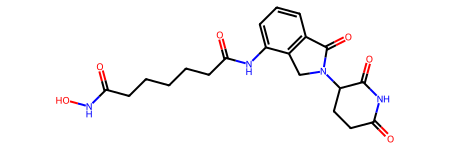

In [27]:
for i, row in test_tmp.iterrows():
    safe_display(Chem.MolFromSmiles(row[protac_col]))
    if i > 10:
        break

In [10]:
# Save to CSV
os.makedirs(os.path.join(data_dir, 'datasets', 'hardest'), exist_ok=True)
train_df.to_csv(os.path.join(data_dir, 'datasets', 'hardest', 'train.csv'), index=False)
test_df.to_csv(os.path.join(data_dir, 'datasets', 'hardest', 'test.csv'), index=False)

## Unique Substructure Splits

In [29]:
for substruct_name, substruct_df in zip(['E3 Binder', 'Linker', 'POI Ligand'], [e3_df, linker_df, poi_df]):
    print('-' * 80)
    print(f'{substruct_name} dataset')
    print('-' * 80)
    substruct_id_col = f'{substruct_name} ID'
    substruct_smi_col = f'{substruct_name} SMILES with direction'

    test_data = []
    test_substruct_ids = []
    protac_df = protacs_splitted_with_directionality.copy()

    for substruct in substruct_df.sort_values('avg_distance', ascending=False)['smiles'].tolist():
        # Starting from the "most different" substruct, get the PROTAC entries that contain it
        tmp = protac_df[protac_df[substruct_smi_col] == substruct]
        # Get all the other substruct with the same ID
        substruct_ids = tmp[substruct_id_col].unique()
        tmp = pd.concat([tmp, protac_df[protac_df[substruct_id_col].isin(substruct_ids)]])

        if tmp.empty:
            continue

        perc = len(tmp) / len(protacs_splitted_with_directionality)
        curr_test_perc = perc
        if test_data:
            curr_test_perc = (len(tmp) + len(pd.concat(test_data, ignore_index=True))) / len(protacs_splitted_with_directionality)
        
        perc_threshold = 0.02
        max_test_perc = 0.12

        if curr_test_perc < max_test_perc:
            # Print current size
            print(f'Number of isolated PROTACs: {len(tmp):4d} ({perc:.1%})')
            # Append to the test data
            test_data.append(tmp)
            test_substruct_ids.extend(tmp[substruct_id_col].unique().tolist())
            # Remove the entries from the PROTAC dataframe that have the same substruct ID
            protac_df = protac_df[~protac_df[substruct_id_col].isin(test_substruct_ids)]

    # Concatenate the test data
    test_df = pd.concat(test_data, ignore_index=True)

    # Isolate the training entries
    train_df = protacs_splitted_with_directionality[~protacs_splitted_with_directionality[protac_col].isin(test_df[protac_col])]

    # Save to CSV
    substruct_name = substruct_name.split(' ')[0].lower()
    os.makedirs(os.path.join(data_dir, 'datasets', f'{substruct_name}_unique'), exist_ok=True)
    train_df.to_csv(os.path.join(data_dir, 'datasets', f'{substruct_name}_unique', 'train.csv'), index=False)
    test_df.to_csv(os.path.join(data_dir, 'datasets', f'{substruct_name}_unique', 'test.csv'), index=False)
    
    # Reporting
    safe_display(train_df)
    safe_display(test_df)
    report_dataset(train_df, test_df)
    # Print the average distance of the substructures in the test set
    print('Average distance of the substructures in the test set:')
    print(f'\t- E3: {e3_df[e3_df["smiles"].isin(test_df[e3_col])]["avg_distance"].mean():.3f}')
    print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(test_df[linker_col])]["avg_distance"].mean():.3f}')
    print(f'\t- POI: {poi_df[poi_df["smiles"].isin(test_df[poi_col])]["avg_distance"].mean():.3f}')

    print('Average distance of the substructures in the training set:')
    print(f'\t- E3: {e3_df[e3_df["smiles"].isin(train_df[e3_col])]["avg_distance"].mean():.3f}')
    print(f'\t- Linker: {linker_df[linker_df["smiles"].isin(train_df[linker_col])]["avg_distance"].mean():.3f}')
    print(f'\t- POI: {poi_df[poi_df["smiles"].isin(train_df[poi_col])]["avg_distance"].mean():.3f}')

--------------------------------------------------------------------------------
E3 Binder dataset
--------------------------------------------------------------------------------
Number of isolated PROTACs:    4 (0.1%)
Number of isolated PROTACs:    4 (0.1%)
Number of isolated PROTACs:   36 (1.2%)
Number of isolated PROTACs:    4 (0.1%)
Number of isolated PROTACs:    8 (0.3%)
Number of isolated PROTACs:    4 (0.1%)
Number of isolated PROTACs:   16 (0.5%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:    4 (0.1%)
Number of isolated PROTACs:    4 (0.1%)
Number of isolated PROTACs:    4 (0.1%)
Number of isolated PROTACs:   52 (1.7%)
Number of isolated PROTACs:   32 (1.0%)
Number of isolated PROTACs:    8 (0.3%)
Number of isolated PROTACs:   16 (0.5%)
Number of isolated PROTACs:    6 (0.2%)
Number of isolated PROTACs:    8 (0.3%)
Number of isolated PROTACs:   70 (2.3%)
Number of isolated PROTACs:    2 (0.1%)
Number of isolated PROTACs:    4 (0.1%)
Number of isolated P

,PROTAC ID,PROTAC SMILES,E3 Binder ID,E3 Binder SMILES,E3 Binder SMILES with direction,Linker ID,Linker SMILES,Linker SMILES with direction,POI Ligand ID,POI Ligand SMILES,POI Ligand SMILES with direction
0,1109,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3371,COCCOCCOCCN(C)C(=O)CCN,[*:2]COCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
1,1109,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3371,COCCOCCOCCN(C)C(=O)CCN,[*:2]COCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
2,2050,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3369,OCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
3,2050,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3369,OCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
4,2696,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCCO...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3370,OCCOCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
...,...,...,...,...,...,...,...,...,...,...,...
3052,2047,O=C1CCC(N2Cc3c(NC(=O)CCCCCCCCCn4cc(Nc5ncc(Cl)c...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,2929,C(=O)CCCCCCCC,[*:2]C(=O)CCCCCCCC[*:1],502,Cn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1,[*:1]Cn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1
3053,2640,O=C1CCC(N2Cc3c(NC(=O)CCCCCCCN4CCN(c5ccc(Nc6ncc...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,3097,C(=O)CCCCCC,[*:2]C(=O)CCCCCC[*:1],65,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC5)c4n...,[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC...
3054,533,O=C1CCC(N2Cc3c(NC(=O)CCCCCCN4CCN(c5ccc(Nc6ncc7...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,3058,C(=O)CCCCC,[*:2]C(=O)CCCCC[*:1],65,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC5)c4n...,[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC...
3055,1434,O=C1CCC(N2Cc3c(NC(=O)COCCOCCOCCOCCn4cc(Nc5ncc(...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,2930,C(=O)COCCOCCOCC,[*:2]C(=O)COCCOCCOCC[*:1],57,OCCn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1,[*:1]OCCn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1


,PROTAC ID,PROTAC SMILES,E3 Binder ID,E3 Binder SMILES,E3 Binder SMILES with direction,Linker ID,Linker SMILES,Linker SMILES with direction,POI Ligand ID,POI Ligand SMILES,POI Ligand SMILES with direction
0,1406,COc1cc(/C=C2\SC(=O)N(Cc3cn(CCCNC(=O)[C@@H](N)C...,258,N=C(N)NCCC[C@H](N)C(N)=O,[*:2]NC(=O)[C@@H](N)CCCNC(=N)N,2925,CCCn1cc()nn1,[*:2]CCCn1cc([*:1])nn1,276,COc1cc(/C=C2\SC(=O)N(C)C2=O)ccc1Oc1ccc(C#N)cc1...,[*:1]CN1C(=O)S/C(=C\c2ccc(Oc3ccc(C#N)cc3C(F)(F...
1,1406,COc1cc(C=C2SC(=O)N(Cc3cn(CCCNC(=O)C(N)CCCNC(=N...,258,N=C(N)NCCC[C@H](N)C(N)=O,[*:2]NC(=O)[C@@H](N)CCCNC(=N)N,2925,CCCn1cc()nn1,[*:2]CCCn1cc([*:1])nn1,276,COc1cc(/C=C2\SC(=O)N(C)C2=O)ccc1Oc1ccc(C#N)cc1...,[*:1]CN1C(=O)S/C(=C\c2ccc(Oc3ccc(C#N)cc3C(F)(F...
2,1406,COc1cc(/C=C2\SC(=O)N(Cc3cn(CCCNC(=O)[C@@H](N)C...,258,N=C(N)NCCC[C@H](N)C(N)=O,[*:2]NC(=O)[C@@H](N)CCCNC(=N)N,2925,CCCn1cc()nn1,[*:2]CCCn1cc([*:1])nn1,276,COc1cc(/C=C2\SC(=O)N(C)C2=O)ccc1Oc1ccc(C#N)cc1...,[*:1]CN1C(=O)S/C(=C\c2ccc(Oc3ccc(C#N)cc3C(F)(F...
3,1406,COc1cc(C=C2SC(=O)N(Cc3cn(CCCNC(=O)C(N)CCCNC(=N...,258,N=C(N)NCCC[C@H](N)C(N)=O,[*:2]NC(=O)[C@@H](N)CCCNC(=N)N,2925,CCCn1cc()nn1,[*:2]CCCn1cc([*:1])nn1,276,COc1cc(/C=C2\SC(=O)N(C)C2=O)ccc1Oc1ccc(C#N)cc1...,[*:1]CN1C(=O)S/C(=C\c2ccc(Oc3ccc(C#N)cc3C(F)(F...
4,1177,COc1cc(/C=C2\SC(=O)N(Cc3cn(CCCNC(=O)[C@@H](N)C...,259,NC(=O)[C@@H](N)Cc1c[nH]cn1,[*:2]NC(=O)[C@@H](N)Cc1c[nH]cn1,2925,CCCn1cc()nn1,[*:2]CCCn1cc([*:1])nn1,276,COc1cc(/C=C2\SC(=O)N(C)C2=O)ccc1Oc1ccc(C#N)cc1...,[*:1]CN1C(=O)S/C(=C\c2ccc(Oc3ccc(C#N)cc3C(F)(F...
...,...,...,...,...,...,...,...,...,...,...,...
360,130,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc(C(...,55,CN[C@@H](C)C(=O)N[C@H](C(=O)N1CCC[C@H]1c1nc(C(...,[*:2]CN1CCC([C@H](NC(=O)[C@H](C)NC)C(=O)N2CCC[...,1462,C,[*:2]C[*:1],464,CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccc(F)cc4F)cc...,[*:1]CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccc(F)cc...
361,3445,CCC(NC(=O)C1CC(NC(=O)COCCOCCOCCOCCOc2cc3nccc(N...,90,CC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](NC(=O)[...,[*:2][C@H]1C[C@@H](C(=O)N[C@H](CC)c2ccccc2)N(C...,3512,NC(=O)COCCOCCOCCOC,[*:2]NC(=O)COCCOCCOCCOC[*:1],321,COc1cc2nccc(Nc3ccc4scnc4c3)c2cc1S(=O)(=O)C(C)(C)C,[*:1]COc1cc2nccc(Nc3ccc4scnc4c3)c2cc1S(=O)(=O)...
362,3445,CC[C@@H](NC(=O)[C@@H]1C[C@H](NC(=O)COCCOCCOCCO...,90,CC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](NC(=O)[...,[*:2][C@H]1C[C@@H](C(=O)N[C@H](CC)c2ccccc2)N(C...,3512,NC(=O)COCCOCCOCCOC,[*:2]NC(=O)COCCOCCOCCOC[*:1],321,COc1cc2nccc(Nc3ccc4scnc4c3)c2cc1S(=O)(=O)C(C)(C)C,[*:1]COc1cc2nccc(Nc3ccc4scnc4c3)c2cc1S(=O)(=O)...
363,3445,CCC(NC(=O)C1CC(NC(=O)COCCOCCOCCOCCOc2cc3nccc(N...,90,CC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H](NC(=O)[...,[*:2][C@H]1C[C@@H](C(=O)N[C@H](CC)c2ccccc2)N(C...,3512,NC(=O)COCCOCCOCCOC,[*:2]NC(=O)COCCOCCOCCOC[*:1],321,COc1cc2nccc(Nc3ccc4scnc4c3)c2cc1S(=O)(=O)C(C)(C)C,[*:1]COc1cc2nccc(Nc3ccc4scnc4c3)c2cc1S(=O)(=O)...


Number of PROTACs in the training set: 2825 (92.4%)
Number of PROTACs in the testing set: 365 (11.9%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 0
Number of entries with same Linker SMILES in the train and test sets: 192
Number of entries with same POI SMILES in the train and test sets: 280
Number of entries with same E3 ID in the train and test sets: 0
Number of entries with same Linker ID in the train and test sets: 192
Number of entries with same POI ID in the train and test sets: 290
Average distance of the substructures in the test set:
	- E3: 0.839
	- Linker: 0.858
	- POI: 0.840
Average distance of the substructures in the training set:
	- E3: 0.755
	- Linker: 0.854
	- POI: 0.832
--------------------------------------------------------------------------------
Linker dataset
----------------------------------------

,PROTAC ID,PROTAC SMILES,E3 Binder ID,E3 Binder SMILES,E3 Binder SMILES with direction,Linker ID,Linker SMILES,Linker SMILES with direction,POI Ligand ID,POI Ligand SMILES,POI Ligand SMILES with direction
0,1109,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3371,COCCOCCOCCN(C)C(=O)CCN,[*:2]COCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
1,1109,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3371,COCCOCCOCCN(C)C(=O)CCN,[*:2]COCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
2,2050,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3369,OCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
3,2050,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3369,OCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
4,2696,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCCO...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3370,OCCOCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
...,...,...,...,...,...,...,...,...,...,...,...
3052,2047,O=C1CCC(N2Cc3c(NC(=O)CCCCCCCCCn4cc(Nc5ncc(Cl)c...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,2929,C(=O)CCCCCCCC,[*:2]C(=O)CCCCCCCC[*:1],502,Cn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1,[*:1]Cn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1
3053,2640,O=C1CCC(N2Cc3c(NC(=O)CCCCCCCN4CCN(c5ccc(Nc6ncc...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,3097,C(=O)CCCCCC,[*:2]C(=O)CCCCCC[*:1],65,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC5)c4n...,[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC...
3054,533,O=C1CCC(N2Cc3c(NC(=O)CCCCCCN4CCN(c5ccc(Nc6ncc7...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,3058,C(=O)CCCCC,[*:2]C(=O)CCCCC[*:1],65,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC5)c4n...,[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC...
3055,1434,O=C1CCC(N2Cc3c(NC(=O)COCCOCCOCCOCCn4cc(Nc5ncc(...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,2930,C(=O)COCCOCCOCC,[*:2]C(=O)COCCOCCOCC[*:1],57,OCCn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1,[*:1]OCCn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1


,PROTAC ID,PROTAC SMILES,E3 Binder ID,E3 Binder SMILES,E3 Binder SMILES with direction,Linker ID,Linker SMILES,Linker SMILES with direction,POI Ligand ID,POI Ligand SMILES,POI Ligand SMILES with direction
0,1458,COc1cc(OC)c(Cl)c(NC(=O)N(C)c2cc(Nc3ccc(N4CCN(C...,98,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,3040,NaN,[*:2][*:1],168,CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC)cc(O...,[*:1]CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC...
1,1458,COc1cc(OC)c(Cl)c(NC(=O)N(C)c2cc(Nc3ccc(N4CCN(C...,98,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,3040,NaN,[*:2][*:1],168,CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC)cc(O...,[*:1]CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC...
2,1444,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,98,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,3040,NaN,[*:2][*:1],422,Nc1nnc(-c2ccccc2O)cc1N1CCNCC1,[*:1]N1CCN(c2cc(-c3ccccc3O)nnc2N)CC1
3,1444,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,98,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,3040,NaN,[*:2][*:1],422,Nc1nnc(-c2ccccc2O)cc1N1CCNCC1,[*:1]N1CCN(c2cc(-c3ccccc3O)nnc2N)CC1
4,1458,COc1cc(OC)c(Cl)c(NC(=O)N(C)c2cc(Nc3ccc(N4CCN(C...,98,CC(=O)N[C@@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@...,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=...,3040,NaN,[*:2][*:1],168,CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC)cc(O...,[*:1]CCN1CCN(c2ccc(Nc3cc(N(C)C(=O)Nc4c(Cl)c(OC...
...,...,...,...,...,...,...,...,...,...,...,...
361,624,NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN(C(=O)C...,57,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,[*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,1550,C#CCCCC,[*:2]C#CCCCC[*:1],612,CC(=O)N1CC[C@H]2CC[C@@H](C(=O)N[C@@H](CCC(N)=O...,[*:1]CC(=O)N1CC[C@H]2CC[C@@H](C(=O)N[C@@H](CCC...
362,624,NC(=O)CCC(NC(=O)C1CCC2CCN(C(=O)CCCCCC#Cc3cccc4...,57,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,[*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,1550,C#CCCCC,[*:2]C#CCCCC[*:1],612,CC(=O)N1CC[C@H]2CC[C@@H](C(=O)N[C@@H](CCC(N)=O...,[*:1]CC(=O)N1CC[C@H]2CC[C@@H](C(=O)N[C@@H](CCC...
363,624,NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN(C(=O)C...,57,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,[*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,1550,C#CCCCC,[*:2]C#CCCCC[*:1],612,CC(=O)N1CC[C@H]2CC[C@@H](C(=O)N[C@@H](CCC(N)=O...,[*:1]CC(=O)N1CC[C@H]2CC[C@@H](C(=O)N[C@@H](CCC...
364,2512,NC(=O)c1sc(-c2ccnc(NC(=O)C3CC3)c2)nc1OCCOCC#Cc...,57,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,[*:2]c1ccc2c(c1)C(=O)N(C1CCC(=O)NC1=O)C2=O,3416,C#CCOC,[*:2]C#CCOC[*:1],210,COc1nc(-c2ccnc(NC(=O)C3CC3)c2)sc1C(N)=O,[*:1]COc1nc(-c2ccnc(NC(=O)C3CC3)c2)sc1C(N)=O


Number of PROTACs in the training set: 2874 (94.0%)
Number of PROTACs in the testing set: 366 (12.0%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 336
Number of entries with same Linker SMILES in the train and test sets: 0
Number of entries with same POI SMILES in the train and test sets: 266
Number of entries with same E3 ID in the train and test sets: 340
Number of entries with same Linker ID in the train and test sets: 0
Number of entries with same POI ID in the train and test sets: 270
Average distance of the substructures in the test set:
	- E3: 0.792
	- Linker: 0.920
	- POI: 0.833
Average distance of the substructures in the training set:
	- E3: 0.784
	- Linker: 0.851
	- POI: 0.833
--------------------------------------------------------------------------------
POI Ligand dataset
------------------------------------

,PROTAC ID,PROTAC SMILES,E3 Binder ID,E3 Binder SMILES,E3 Binder SMILES with direction,Linker ID,Linker SMILES,Linker SMILES with direction,POI Ligand ID,POI Ligand SMILES,POI Ligand SMILES with direction
0,1109,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3371,COCCOCCOCCN(C)C(=O)CCN,[*:2]COCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
1,1109,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCC(=O...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3371,COCCOCCOCCN(C)C(=O)CCN,[*:2]COCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
2,2050,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3369,OCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
3,2050,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCC(...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3369,OCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
4,2696,C=CC(=O)N1CCN(c2nc(NCCC(=O)N(C)CCOCCOCCOCCOCCO...,89,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)N[C@@...,[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)...,3370,OCCOCCOCCOCCOCCN(C)C(=O)CCN,[*:2]OCCOCCOCCOCCOCCN(C)C(=O)CCN[*:1],610,C=CC(=O)N1CCN(c2ncnc3c(F)c(-c4cc(O)cc5ccccc45)...,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O...
...,...,...,...,...,...,...,...,...,...,...,...
3052,2047,O=C1CCC(N2Cc3c(NC(=O)CCCCCCCCCn4cc(Nc5ncc(Cl)c...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,2929,C(=O)CCCCCCCC,[*:2]C(=O)CCCCCCCC[*:1],502,Cn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1,[*:1]Cn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1
3053,2640,O=C1CCC(N2Cc3c(NC(=O)CCCCCCCN4CCN(c5ccc(Nc6ncc...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,3097,C(=O)CCCCCC,[*:2]C(=O)CCCCCC[*:1],65,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC5)c4n...,[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC...
3054,533,O=C1CCC(N2Cc3c(NC(=O)CCCCCCN4CCN(c5ccc(Nc6ncc7...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,3058,C(=O)CCCCC,[*:2]C(=O)CCCCC[*:1],65,CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC5)c4n...,[*:1]CN1CCN(c2ccc(Nc3ncc4nc(Nc5ccccc5)n(C5CCCC...
3055,1434,O=C1CCC(N2Cc3c(NC(=O)COCCOCCOCCOCCn4cc(Nc5ncc(...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,2930,C(=O)COCCOCCOCC,[*:2]C(=O)COCCOCCOCC[*:1],57,OCCn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1,[*:1]OCCn1cc(Nc2ncc(Cl)c(NCc3cc(F)ccc3F)n2)cn1


,PROTAC ID,PROTAC SMILES,E3 Binder ID,E3 Binder SMILES,E3 Binder SMILES with direction,Linker ID,Linker SMILES,Linker SMILES with direction,POI Ligand ID,POI Ligand SMILES,POI Ligand SMILES with direction
0,890,CC(C)CC(NC(=O)C(O)C(N)Cc1ccccc1)C(=O)NCCOCCOCC...,123,CNC(=O)[C@H](CC(C)C)NC(=O)[C@@H](O)[C@H](N)Cc1...,[*:2]CNC(=O)[C@H](CC(C)C)NC(=O)[C@@H](O)[C@H](...,3470,COCCOCC(=O)Nc1cccc()c1,[*:2]COCCOCC(=O)Nc1cccc([*:1])c1,283,O=CNO,[*:1]C(=O)NO
1,890,CC(C)C[C@H](NC(=O)[C@@H](O)[C@H](N)Cc1ccccc1)C...,123,CNC(=O)[C@H](CC(C)C)NC(=O)[C@@H](O)[C@H](N)Cc1...,[*:2]CNC(=O)[C@H](CC(C)C)NC(=O)[C@@H](O)[C@H](...,3470,COCCOCC(=O)Nc1cccc()c1,[*:2]COCCOCC(=O)Nc1cccc([*:1])c1,283,O=CNO,[*:1]C(=O)NO
2,3511,O=C(CCCCCC(=O)Nc1cccc2c1CN(C1CCC(=O)NC1=O)C2=O)NO,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,3058,C(=O)CCCCC,[*:2]C(=O)CCCCC[*:1],283,O=CNO,[*:1]C(=O)NO
3,2599,O=C(CCCCCCC(=O)Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O...,153,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,3097,C(=O)CCCCCC,[*:2]C(=O)CCCCCC[*:1],283,O=CNO,[*:1]C(=O)NO
4,221,O=C(CCCCCCC(=O)Nc1cccc2c1CN(C1CCC(=O)NC1=O)C2=...,48,Nc1cccc2c1CN([C@H]1CCC(=O)NC1=O)C2=O,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1,3097,C(=O)CCCCCC,[*:2]C(=O)CCCCCC[*:1],283,O=CNO,[*:1]C(=O)NO
...,...,...,...,...,...,...,...,...,...,...,...
360,634,O=C(CCCCCCC(=O)NN=Cc1ccc(OCCOCCOCCn2cc(CNc3ccc...,153,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,3002,Cc1cn(CCOCCOC)nn1,[*:2]Cc1cn(CCOCCOC[*:1])nn1,297,COc1ccc(C=NNC(=O)CCCCCCC(=O)NO)cc1,[*:1]COc1ccc(/C=N/NC(=O)CCCCCCC(=O)NO)cc1
361,778,O=C(CCCCCCC(=O)NN=Cc1ccc(OCCOCCn2cc(CNc3cccc4c...,153,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,3001,Cc1cn(CCOC)nn1,[*:2]Cc1cn(CCOC[*:1])nn1,297,COc1ccc(C=NNC(=O)CCCCCCC(=O)NO)cc1,[*:1]COc1ccc(/C=N/NC(=O)CCCCCCC(=O)NO)cc1
362,1876,O=C(CCCCCCC(=O)NN=Cc1ccc(OCCn2cc(CNc3cccc4c3C(...,153,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,2423,Cc1cn(C)nn1,[*:2]Cc1cn(C[*:1])nn1,297,COc1ccc(C=NNC(=O)CCCCCCC(=O)NO)cc1,[*:1]COc1ccc(/C=N/NC(=O)CCCCCCC(=O)NO)cc1
363,239,Nc1nnc(-c2ccccc2O)cc1N1CCN(c2cccc(CN3CCN(C(=O)...,57,O=C1CCC(N2C(=O)c3ccccc3C2=O)C(=O)N1,[*:2]c1ccc2c(c1)C(=O)N(C1CCC(=O)NC1=O)C2=O,3639,N1CCC(C(=O)N2CCN(Cc3cccc()c3)CC2)CC1,[*:2]N1CCC(C(=O)N2CCN(Cc3cccc([*:1])c3)CC2)CC1,35,Nc1nnc(-c2ccccc2O)cc1N1CCNC2(CC2)C1,[*:1]N1CCN(c2cc(-c3ccccc3O)nnc2N)CC12CC2


Number of PROTACs in the training set: 2867 (93.8%)
Number of PROTACs in the testing set: 365 (11.9%)
Number of PROTAC SMILESs that are in both the training and testing sets: 0
Number of PROTAC IDs that are in both the training and testing sets: 0
Number of entries with same E3 SMILES in the train and test sets: 361
Number of entries with same Linker SMILES in the train and test sets: 179
Number of entries with same POI SMILES in the train and test sets: 0
Number of entries with same E3 ID in the train and test sets: 365
Number of entries with same Linker ID in the train and test sets: 179
Number of entries with same POI ID in the train and test sets: 0
Average distance of the substructures in the test set:
	- E3: 0.788
	- Linker: 0.855
	- POI: 0.877
Average distance of the substructures in the training set:
	- E3: 0.784
	- Linker: 0.854
	- POI: 0.829
